<a href="https://colab.research.google.com/github/keerthanaponugumati/research-projects/blob/main/PINN_Universal_Oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.net(t)


model = PINN()


In [2]:

delta = 0.2
omega_0 = 2.0

def physics_loss_function(t_physics, model):

    x = model(t_physics)


    dx_dt = torch.autograd.grad(x, t_physics, grad_outputs=torch.ones_like(x),
                                create_graph=True)[0]


    d2x_dt2 = torch.autograd.grad(dx_dt, t_physics, grad_outputs=torch.ones_like(dx_dt),
                                  create_graph=True)[0]


    physics_equation = d2x_dt2 + (2 * delta * dx_dt) + (omega_0**2 * x)


    loss_physics = torch.mean(physics_equation**2)

    return loss_physics

In [3]:

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


t_physics = torch.rand(500, 1) * 10
t_physics.requires_grad = True


t_boundary = torch.tensor([[0.0]])
x_boundary_true = torch.tensor([[1.0]])


epochs = 15000
for i in range(epochs):

    optimizer.zero_grad()


    x_boundary_pred = model(t_boundary)
    loss_boundary = torch.mean((x_boundary_pred - x_boundary_true)**2)


    loss_physics = physics_loss_function(t_physics, model)


    total_loss = loss_boundary + loss_physics


    total_loss.backward()


    optimizer.step()

    if i % 3000 == 0:
        print(f"Epoch {i} | Total Loss: {total_loss.item():.5f}")

Epoch 0 | Total Loss: 2.56201
Epoch 3000 | Total Loss: 0.05636
Epoch 6000 | Total Loss: 0.04618
Epoch 9000 | Total Loss: 0.03922
Epoch 12000 | Total Loss: 0.02705


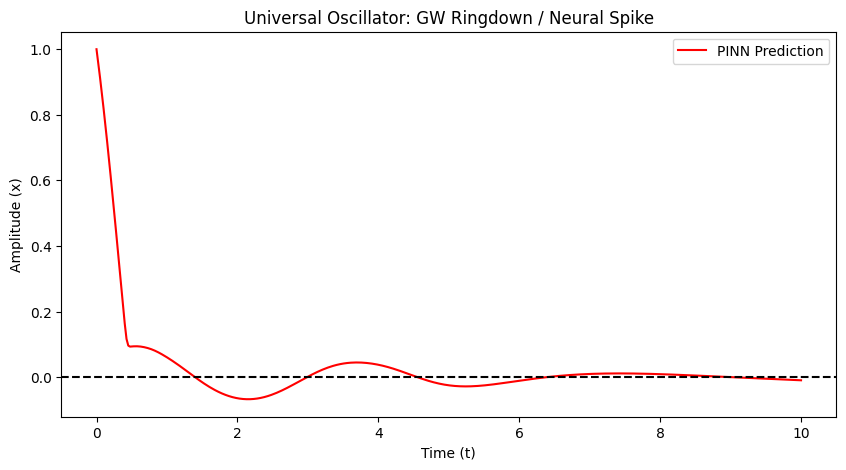

In [5]:

t_test = torch.linspace(0, 10, 400).view(-1, 1)


x_pred = model(t_test).detach().numpy()


plt.figure(figsize=(10, 5))
plt.plot(t_test.numpy(), x_pred, color='red', label="PINN Prediction")
plt.title("Universal Oscillator: GW Ringdown / Neural Spike")
plt.xlabel("Time (t)")
plt.ylabel("Amplitude (x)")
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()